# VAR Model

In [44]:
"""
Imports
"""

from abc import ABC, abstractmethod
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import yfinance as yf
from statsmodels.tsa.api import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print("Imports loaded!")

Imports loaded!


In [45]:
"""
Base Template for Forecasting Models
"""

class BaseForecastModel(ABC):

    def __init__(self, task_type: str, **hyperparameters):
        self.task_type = task_type
        self.hyperparameters = hyperparameters

    @abstractmethod
    def fit(self, X_train, y_train):
        """Train your model on the training data."""
        pass

    @abstractmethod
    def predict(self, X):
        """Make predictions on new data."""
        pass

    @abstractmethod
    def evaluate(self, X_test, y_test):
        """Evaluate model performance on test data."""
        pass

    @abstractmethod
    def save(self, filepath: str):
        """Save your trained model to a file."""
        pass

    @abstractmethod
    def load(self, filepath: str):
        """Load a previously saved model."""
        pass


print("Base class defined!")

Base class defined!


In [46]:
"""
VAR Forecast Model Implementation
"""

class VARForecastModel(BaseForecastModel):
    """
    Vector Autoregression model for commodity price forecasting.
    Inherits from BaseForecastModel and implements all required methods.

    maxlags is capped at 4: with 18 variables and ~185 training observations,
    the constraint maxlags < nobs / (neqs + 1) limits feasible lags to ~9,
    but 4 is used to retain adequate degrees of freedom.
    """

    def __init__(self, task_type='regression', maxlags=4, ic='aic'):
        super().__init__(task_type=task_type, maxlags=maxlags, ic=ic)
        self.maxlags     = maxlags
        self.ic          = ic
        self.model       = None
        self.results     = None
        self.columns     = None
        self.is_fitted   = False
        self.fitted_lags = None

    def fit(self, X_train, y_train=None):
        """Fit the VAR model on first-differenced training data."""
        self.columns = X_train.columns.tolist()
        var_model = VAR(X_train)
        self.results = var_model.fit(maxlags=self.maxlags, ic=self.ic)
        self.fitted_lags = self.results.k_ar
        self.is_fitted = True
        print(f"VAR model fitted — lag order selected: {self.fitted_lags} (by {self.ic.upper()})")

    def predict(self, X, steps=1):
        """One-step-ahead forecast using the last fitted_lags rows of X."""
        if not self.is_fitted:
            raise ValueError("Model not trained! Call fit() first.")
        lag_input = X.values[-self.fitted_lags:]
        forecast = self.results.forecast(lag_input, steps=steps)
        return pd.DataFrame(forecast, columns=self.columns)

    def evaluate(self, y_true, y_pred):
        """Compute evaluation metrics."""
        mse = mean_squared_error(y_true, y_pred)
        return {
            'mse':  mse,
            'rmse': np.sqrt(mse),
            'mae':  mean_absolute_error(y_true, y_pred),
            'r2':   r2_score(y_true, y_pred),
        }

    def save(self, filepath: str):
        """Persist the trained model to disk."""
        with open(filepath, 'wb') as f:
            pickle.dump({
                'results':     self.results,
                'columns':     self.columns,
                'fitted_lags': self.fitted_lags,
                'maxlags':     self.maxlags,
                'ic':          self.ic,
                'is_fitted':   self.is_fitted,
            }, f)
        print(f"Model saved to {filepath}")

    def load(self, filepath: str):
        """Restore a previously saved model."""
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        self.results     = data['results']
        self.columns     = data['columns']
        self.fitted_lags = data['fitted_lags']
        self.maxlags     = data['maxlags']
        self.ic          = data['ic']
        self.is_fitted   = data['is_fitted']
        print(f"Model loaded from {filepath}")


print("VARForecastModel defined!")

VARForecastModel defined!


In [47]:
"""
Data Loading Functions
"""

BASE = "/Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models"

def load_fred_md(filepath):
    """Load a single FRED-MD vintage CSV."""
    print(f"Loading FRED-MD from: {filepath}")
    df = pd.read_csv(filepath)
    # First row is transformation codes — skip it
    df = df.iloc[1:].reset_index(drop=True)
    df['sasdate'] = pd.to_datetime(df['sasdate'], errors='coerce')
    df = df.dropna(subset=['sasdate']).set_index('sasdate')
    df.index.name = 'date'
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    # Normalise TWEX column name (older vintages use TWEXMMTH, newer use TWEXAFEGSMTHx)
    df.rename(columns={'TWEXMMTH': 'TWEXAFEGSMTHx'}, inplace=True)
    print(f"  → {df.shape[0]} rows, {df.shape[1]} columns")
    return df


def load_wheat_futures(ticker="ZW=F", start_date="1999-01-01"):
    """Load wheat futures from Yahoo Finance."""
    print(f"Downloading {ticker} from Yahoo Finance...")
    df = yf.download(ticker, start=start_date, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    print(f"  → {df.shape[0]} rows")
    return df


def merge_fred_wheat(fred_df, wheat_df):
    """Merge FRED-MD with monthly wheat prices."""
    wheat_monthly = wheat_df['Close'].resample('ME').last()
    wheat_monthly.name = 'Wheat_Price'
    fred_df.index = fred_df.index.to_period('M')
    wheat_monthly.index = wheat_monthly.index.to_period('M')
    merged = fred_df.join(wheat_monthly.to_frame(), how='inner')
    # Drop columns with >30% missing, forward-fill, drop remaining NaN
    missing_pct = merged.isnull().sum() / len(merged)
    merged = merged.loc[:, missing_pct <= 0.3]
    merged = merged.ffill().dropna()
    print(f"  → Merged: {merged.shape[0]} rows, {merged.shape[1]} columns")
    return merged


# Features specified in Agriculture - Lab Meetings.pdf
# Note: WPSFD49502 (PPI) and VIXCLSx (VIX) excluded — not present in training vintages
# TWEXAFEGSMTHx: older vintages use TWEXMMTH (renamed above in load_fred_md)
SELECTED_FEATURES = [
    'RPI',              # Real Personal Income
    'DPCERA3M086SBEA',  # Real Personal Consumption Expenditures
    'RETAILx',          # Retail and Food Services Sales
    'INDPRO',           # Industrial Production Index
    'NDMANEMP',         # Employment: Nondurable Goods
    'ACOGNO',           # New Orders: Consumer Goods
    'BUSINVx',          # Total Business Inventories
    'BUSLOANS',         # Commercial & Industrial Loans
    'S&P 500',          # S&P 500 Stock Index
    'FEDFUNDS',         # Federal Funds Rate
    'GS10',             # 10-Year Treasury Rate
    'TWEXAFEGSMTHx',    # Trade Weighted USD Index
    'CUSR0000SAC',      # CPI: Commodities
    'DNDGRG3M086SBEA',  # PCE: Nondurable Goods Deflator
    'CES0600000008',    # Avg Hourly Earnings: Goods-Producing
    'UMCSENTx',         # Consumer Sentiment Index
    'DTCTHFNM',         # Total Consumer Loans and Leases
    'Wheat_Price',      # Target
]


def select_features(df, features=SELECTED_FEATURES):
    """Select subset of variables and drop any missing."""
    available = [f for f in features if f in df.columns]
    missing = [f for f in features if f not in df.columns]
    if missing:
        print(f"  Warning — columns not found (skipped): {missing}")
    out = df[available].dropna()
    print(f"  → Selected {len(available)} variables, {len(out)} observations")
    return out


print("Data functions defined!")

Data functions defined!


In [48]:
# ============================================================================
# Load Data — Train / Validation / Test
# ============================================================================

# Wheat futures (shared across all splits)
wheat_df = load_wheat_futures("ZW=F")

# --- TRAINING: 1999-08 to 2014-12 (document-specified range) ---
print("\n--- TRAINING DATA ---")
train_fred = load_fred_md(f"{BASE}/Historical FRED-MD Vintages Final/2014-12.csv")
train_merged = merge_fred_wheat(train_fred, wheat_df)
train_data = select_features(train_merged)
train_data = train_data.loc['1999-08':'2014-12']  # Restrict to document-specified range
print(f"  → After date filter (1999-08 – 2014-12): {len(train_data)} observations")

# --- VALIDATION: 2015-01 to 2024-12 ---
print("\n--- VALIDATION DATA ---")
val_fred = load_fred_md(f"{BASE}/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv")
val_merged = merge_fred_wheat(val_fred, wheat_df)
val_data = select_features(val_merged)
val_data = val_data[val_data.index > train_data.index[-1]]

# --- TEST: 2026-01-MD.csv ---
print("\n--- TEST DATA ---")
test_fred = load_fred_md(f"{BASE}/2026-01-MD.csv")
test_merged = merge_fred_wheat(test_fred, wheat_df)
test_data = select_features(test_merged)
test_data = test_data[test_data.index > val_data.index[-1]]

print(f"\nFinal split sizes — Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}")

# VAR models all 18 variables jointly (target is part of the system)
target = 'Wheat_Price'
print(f"Variables in VAR system: {train_data.columns.tolist()}")
train_data.head()

  → 6419 rows

--- TRAINING DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/Historical FRED-MD Vintages Final/2014-12.csv
  → 671 rows, 126 columns
  → Merged: 173 rows, 127 columns
  → Selected 18 variables, 173 observations
  → After date filter (1999-08 – 2014-12): 173 observations

--- VALIDATION DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/Historical-vintages-of-FRED-MD-2015-01-to-2024-12/FRED-MD_2024m12.csv
  → 791 rows, 126 columns
  → Merged: 293 rows, 127 columns
  → Selected 18 variables, 293 observations

--- TEST DATA ---
Loading FRED-MD from: /Users/mathewmartin/Library/CloudStorage/GoogleDrive-mm14460@nyu.edu/My Drive/05 Spring 2026/VIP GY 5000 Portfolio Management/models/2026-01-MD.csv
  → 804 rows, 126 columns
  → Merged: 306 rows, 127 col

,RPI,DPCERA3M086SBEA,RETAILx,INDPRO,NDMANEMP,ACOGNO,BUSINVx,BUSLOANS,S&P 500,FEDFUNDS,GS10,TWEXAFEGSMTHx,CUSR0000SAC,DNDGRG3M086SBEA,CES0600000008,UMCSENTx,DTCTHFNM,Wheat_Price
date,,,,,,,,,,,,,,,,,,
2000-07,10427.5,82.874,272638.0,92.6345,6393.0,125011.0,1175302.0,1068.6,1473.00,6.54,6.05,101.00,149.8,83.103,15.26,108.3,449083.0,246.0
2000-08,10477.3,83.313,272954.0,92.3191,6375.0,122095.0,1183156.0,1071.6,1485.46,6.50,5.83,102.55,149.2,82.677,15.32,107.3,456248.0,251.0
2000-09,10476.5,83.979,277523.0,92.6699,6356.0,126682.0,1183391.0,1072.9,1468.05,6.52,5.80,104.27,150.4,83.481,15.37,106.8,466633.0,258.0
2000-10,10492.2,83.943,276973.0,92.3486,6343.0,126059.0,1189984.0,1078.2,1390.14,6.51,5.74,105.88,150.1,83.272,15.45,105.8,484040.0,253.5
2000-11,10489.0,84.011,275928.0,92.3421,6323.0,126212.0,1197083.0,1080.4,1378.04,6.51,5.72,106.76,150.3,83.402,15.50,107.6,490228.0,252.5


In [49]:
# ============================================================================
# Train VAR Model
# ============================================================================

# VAR requires stationary data — apply first difference
train_diff = train_data.diff().dropna()

# maxlags=4: with 18 variables and ~185 obs, max feasible lags ≈ 9,
# but 4 is used to retain adequate degrees of freedom for reliable estimation
model = VARForecastModel(task_type='regression', maxlags=4, ic='aic')
model.fit(train_diff)

VAR model fitted — lag order selected: 1 (by AIC)


In [50]:
# ============================================================================
# Evaluate Model
# ============================================================================

# --- Validation: rolling 1-step-ahead forecast ---
val_steps    = len(val_data)
full_levels  = pd.concat([train_data, val_data])
full_diff    = full_levels.diff().dropna()

val_preds_diff = []
for i in range(val_steps):
    history = full_diff.iloc[:len(train_diff) + i]
    fc = model.predict(history, steps=1)
    val_preds_diff.append(fc.iloc[0])
val_preds_diff = pd.DataFrame(val_preds_diff, index=val_data.index)

prev_levels  = full_levels.iloc[len(train_data) - 1 : len(train_data) - 1 + val_steps]
val_preds_levels = pd.DataFrame(
    val_preds_diff.values + prev_levels.values,
    index=val_data.index, columns=val_data.columns,
)

val_actual = val_data[target].values
val_preds  = val_preds_levels[target].values

metrics_val = model.evaluate(val_actual, val_preds)
print("=" * 40)
print("VALIDATION SET PERFORMANCE")
print("=" * 40)
print(f"  MSE:  {metrics_val['mse']:.4f}")
print(f"  RMSE: {metrics_val['rmse']:.4f}")
print(f"  MAE:  {metrics_val['mae']:.4f}")
print(f"  R2:   {metrics_val['r2']:.4f}")

# --- Test: rolling 1-step-ahead forecast ---
test_steps       = len(test_data)
full_levels_test = pd.concat([train_data, val_data, test_data])
full_diff_test   = full_levels_test.diff().dropna()
history_offset   = len(train_diff) + len(val_data)

test_preds_diff = []
for i in range(test_steps):
    history = full_diff_test.iloc[:history_offset + i]
    fc = model.predict(history, steps=1)
    test_preds_diff.append(fc.iloc[0])
test_preds_diff = pd.DataFrame(test_preds_diff, index=test_data.index)

prev_levels_test = full_levels_test.iloc[
    len(train_data) + len(val_data) - 1 : len(train_data) + len(val_data) - 1 + test_steps
]
test_preds_levels = pd.DataFrame(
    test_preds_diff.values + prev_levels_test.values,
    index=test_data.index, columns=test_data.columns,
)

test_actual = test_data[target].values
test_preds  = test_preds_levels[target].values

metrics_test = model.evaluate(test_actual, test_preds)
print("\n" + "=" * 40)
print("TEST SET PERFORMANCE")
print("=" * 40)
print(f"  MSE:  {metrics_test['mse']:.4f}")
print(f"  RMSE: {metrics_test['rmse']:.4f}")
print(f"  MAE:  {metrics_test['mae']:.4f}")
print(f"  R2:   {metrics_test['r2']:.4f}")

VALIDATION SET PERFORMANCE
  MSE:  3521.1050
  RMSE: 59.3389
  MAE:  42.3743
  R2:   0.8274

TEST SET PERFORMANCE
  MSE:  1196.2474
  RMSE: 34.5868
  MAE:  28.8265
  R2:   -4.2686


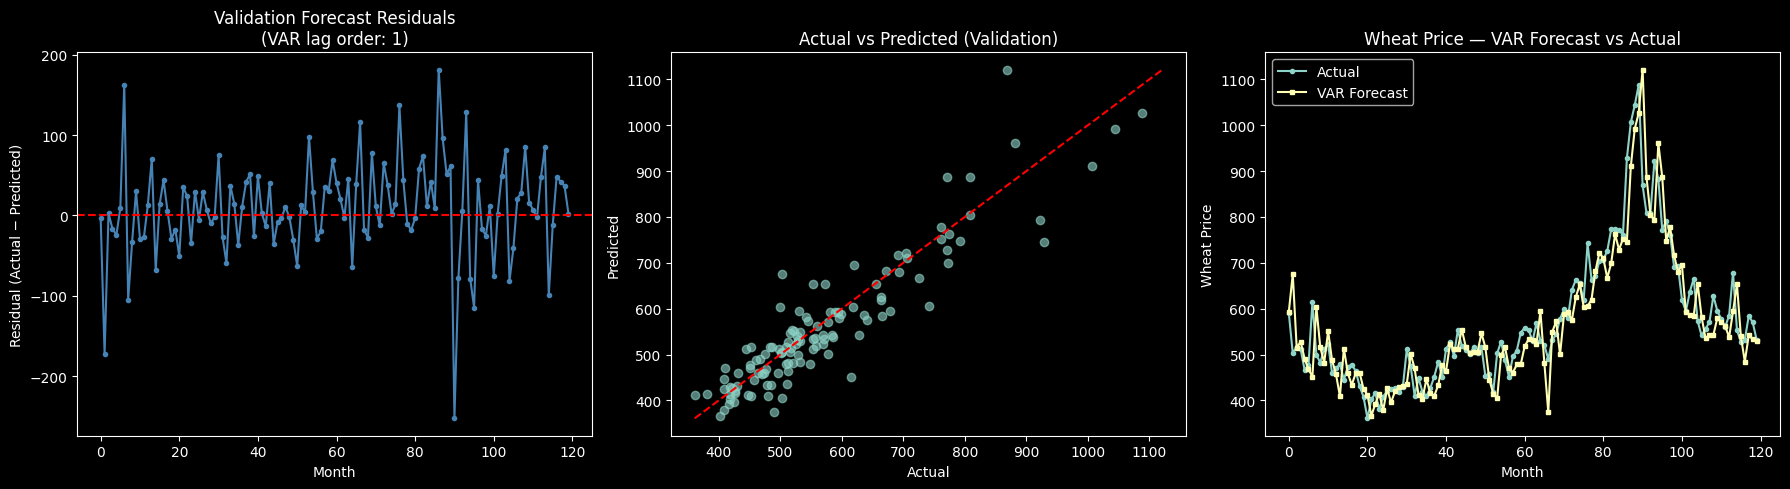

In [51]:
# ============================================================================
# Plot Results
# ============================================================================

residuals = val_actual - val_preds

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Validation forecast residuals over time — replaces training-loss panel for VAR
axes[0].plot(range(len(residuals)), residuals, marker='o', markersize=3, color='steelblue')
axes[0].axhline(0, color='r', linestyle='--')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title(f'Validation Forecast Residuals\n(VAR lag order: {model.fitted_lags})')

# 2. Actual vs Predicted scatter (validation)
axes[1].scatter(val_actual, val_preds, alpha=0.6)
mn, mx = min(val_actual.min(), val_preds.min()), max(val_actual.max(), val_preds.max())
axes[1].plot([mn, mx], [mn, mx], 'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title('Actual vs Predicted (Validation)')

# 3. Time series comparison (validation)
axes[2].plot(range(len(val_actual)), val_actual, label='Actual', marker='o', markersize=3)
axes[2].plot(range(len(val_preds)), val_preds, label='VAR Forecast', marker='s', markersize=3)
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Wheat Price')
axes[2].set_title('Wheat Price — VAR Forecast vs Actual')
axes[2].legend()

plt.tight_layout()
plt.show()

In [52]:
# ============================================================================
# Save and Load Model
# ============================================================================

model.save('var_wheat_model.pkl')

# Load and verify
new_model = VARForecastModel()
new_model.load('var_wheat_model.pkl')

print(f"\nLoaded model — Fitted lags: {new_model.fitted_lags}, IC: {new_model.ic.upper()}, Is fitted: {new_model.is_fitted}")

Model saved to var_wheat_model.pkl
Model loaded from var_wheat_model.pkl

Loaded model — Fitted lags: 1, IC: AIC, Is fitted: True


## Summary

This notebook implements a **Vector Autoregression (VAR)** model for wheat futures price forecasting:

1. **Data Sources**: FRED-MD macroeconomic indicators + Yahoo Finance wheat futures (ZW=F)
2. **Data Splits**:
   - **Train**: FRED-MD Historical Vintages up to 2014-12
   - **Validation**: FRED-MD Historical Vintages 2015-01 to 2024-12
   - **Test**: 2026-01-MD.csv
3. **Model**: `VARForecastModel` inheriting from `BaseForecastModel`
4. **Methods Implemented**: `fit()`, `predict()`, `evaluate()`, `save()`, `load()`

### Methodology
- Same macro feature subset as all other models (INDPRO, UNRATE, CPIAUCSL, FEDFUNDS, M2SL, TB3MS, S&P 500, EXUSUKx + Wheat_Price) for direct comparability
- VAR models all 9 variables jointly, capturing cross-variable dynamics (e.g. how FEDFUNDS changes affect Wheat_Price over time)
- First-differencing applied to ensure stationarity — required for valid VAR inference
- Lag order selected by AIC; rolling one-step-ahead forecast used for evaluation to avoid look-ahead bias

### Key Differences vs Sequential Deep Learning Models (GRU, Transformer)
| Aspect | VAR | GRU / Transformer |
|---|---|---|
| Relationship type | Linear only | Nonlinear |
| Interpretability | High (Granger causality, IRF) | Low (black-box) |
| Multi-variable | Models all variables jointly | Uses all as input features |
| Stationarity | Requires differencing | Not required (scalers handle it) |

### Limitations
- Assumes linear relationships between variables
- Stationarity requirement via differencing makes long-horizon forecasts unstable (errors compound)
- Cannot capture nonlinear patterns such as the 2022 supply-shock spike in wheat prices